In [1]:
pip install scikit-surprise


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Importing Libraries

from surprise import Dataset, Reader, SVD, KNNBasic
from surprise.model_selection import cross_validate, train_test_split

import pandas as pd
import os
import matplotlib.pyplot as plt

In [3]:
# Load data from CSV file
file_path = "ratings_small.csv"  # Replace with the actual path to your file

# Create a Surprise Reader to parse the ratings
reader = Reader(line_format = "user item rating timestamp", sep = ",", skip_lines = 1)

# Load the dataset with the reader
data = Dataset.load_from_file(file_path, reader)

In [4]:
# Split the dataset into training and testing sets
from surprise.model_selection import KFold
trainset, testset = train_test_split(data, test_size = 0.20)
kf = KFold(n_splits=5, random_state=42, shuffle=True)

In [5]:
svd_model = SVD()
pmf_results = cross_validate(svd_model, data, measures = ["MAE", "RMSE"], cv = kf, verbose = True)

# Train the model on the entire dataset
svd_model.fit(trainset)

Evaluating MAE, RMSE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     0.6875  0.6878  0.6907  0.6894  0.6942  0.6899  0.0024  
RMSE (testset)    0.8936  0.8923  0.8984  0.8961  0.9001  0.8961  0.0029  
Fit time          0.66    0.69    0.63    0.64    0.63    0.65    0.02    
Test time         0.16    0.06    0.11    0.06    0.06    0.09    0.04    


In [6]:
knn_user_model = KNNBasic(sim_options = {"user_based": True})
user_results = cross_validate(knn_user_model, data, measures = ["MAE", "RMSE"], cv = kf, verbose = True)

# Train the user-based model on the entire dataset
knn_user_model.fit(trainset)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating MAE, RMSE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     0.7450  0.7390  0.7477  0.7405  0.7452  0.7435  0.0032  
RMSE (testset)    0.9678  0.9629  0.9706  0.9677  0.9663  0.9671  0.0025  
Fit time          0.05    0.06    0.06    0.07    0.06    0.06    0.00    
Test time         0.73    0.65    1.02    0.67    0.71    0.75    0.13    
Computing the msd similarity matrix...
Done computing similarity matrix.


In [7]:
knn_item_model = KNNBasic(sim_options = {"user_based": False})
item_results = cross_validate(knn_item_model, data, measures = ["MAE", "RMSE"], cv = kf, verbose = True)

# Train the item-based model on the entire dataset
knn_item_model.fit(trainset)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating MAE, RMSE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     0.7172  0.7169  0.7227  0.7179  0.7306  0.7211  0.0052  
RMSE (testset)    0.9295  0.9281  0.9396  0.9323  0.9433  0.9346  0.0059  
Fit time          2.52    1.98    2.18    2.07    2.16    2.18    0.18    
Test time         3.09    2.86    3.00    2.87    3.05    2.97    0.09    
Computing the msd similarity matrix...
Done computing similarity matrix.


In [8]:
df_mae_rmse = pd.DataFrame({
    "Model": ["Probabilistic Matrix Factorization (PMF)", "User-based Collaborative Filtering", "Item-based Collaborative Filtering"],
    "Average_MAE": [sum(pmf_results['test_mae']) / 5, sum(user_results['test_mae']) / 5, sum(item_results['test_mae']) / 5],
    "Average_RMSE": [sum(pmf_results['test_rmse']) / 5, sum(user_results['test_rmse']) / 5, sum(item_results['test_rmse']) / 5]
})
df_mae_rmse

,Model,Average_MAE,Average_RMSE
0,Probabilistic Matrix Factorization (PMF),0.689921,0.896106
1,User-based Collaborative Filtering,0.743468,0.967055
2,Item-based Collaborative Filtering,0.721062,0.934569


In [9]:
from surprise.model_selection import GridSearchCV

# User-Based CF
user_param_grid = {
    'k': [10, 20, 30, 40, 50],
    'sim_options': {
        'name': ['cosine', 'msd', 'pearson'],
        'user_based': [True]  # Force user-based CF
    }
}

# Item-Based CF
item_param_grid = {
    'k': [10, 20, 30, 40, 50],
    'sim_options': {
        'name': ['cosine', 'msd', 'pearson'],
        'user_based': [False]  # Force item-based CF
    }
}

# Grid search for User-Based CF (only user_based=True)
user_results = GridSearchCV(KNNBasic, user_param_grid, measures=['rmse', 'mae'], cv=5)
user_results.fit(data)

# Grid search for Item-Based CF (only user_based=False)
item_results = GridSearchCV(KNNBasic, item_param_grid, measures=['rmse', 'mae'], cv=5)
item_results.fit(data)

# Print results
print("User-Based CF - Best RMSE:", user_results.best_score['rmse'])
print("User-Based CF - Best Params:", user_results.best_params['rmse'])
print("Item-Based CF - Best RMSE:", item_results.best_score['rmse'])
print("Item-Based CF - Best Params:", item_results.best_params['rmse'])

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson si

In [10]:
# Cosine similarity
algo_UBCF_cosine = KNNBasic(sim_options = {"name": "cosine", "user_based": True})
CV_UBCF_cosine = cross_validate(algo_UBCF_cosine, data, measures = ["MAE", "RMSE"], cv = kf, verbose = True)

# MSD (Mean Squared Difference) similarity
algo_UBCF_msd = KNNBasic(sim_options = {"name": "msd", "user_based": True})
CV_UBCF_msd = cross_validate(algo_UBCF_msd, data, measures = ["MAE", "RMSE"], cv = kf, verbose = True)

# Pearson similarity
algo_UBCF_pearson = KNNBasic(sim_options = {"name": "pearson", "user_based": True})
CV_UBCF_pearson = cross_validate(algo_UBCF_pearson, data, measures = ["MAE", "RMSE"], cv = kf, verbose = True)


Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Evaluating MAE, RMSE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     0.7685  0.7619  0.7712  0.7644  0.7683  0.7668  0.0033  
RMSE (testset)    0.9935  0.9881  0.9959  0.9931  0.9916  0.9924  0.0026  
Fit time          0.07    0.07    0.07    0.07    0.09    0.08    0.01    
Test time         0.64    0.70    0.66    0.67    0.77    0.69    0.05    
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
D

In [11]:
# Cosine similarity
algo_IBCF_cosine = KNNBasic(sim_options = {"name": "cosine", "user_based": False})
CV_IBCF_cosine = cross_validate(algo_IBCF_cosine, data, measures = ["MAE", "RMSE"], cv = kf, verbose = True)

# MSD (Mean Squared Difference) similarity
algo_IBCF_msd = KNNBasic(sim_options = {"name": "msd", "user_based": False})
CV_IBCF_msd = cross_validate(algo_IBCF_msd, data, measures = ["MAE", "RMSE"], cv = kf, verbose = True)

# Pearson similarity
algo_IBCF_pearson = KNNBasic(sim_options = {"name": "pearson", "user_based": False})
CV_IBCF_pearson = cross_validate(algo_IBCF_pearson, data, measures = ["MAE", "RMSE"], cv = kf, verbose = True)

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Evaluating MAE, RMSE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     0.7696  0.7711  0.7781  0.7718  0.7834  0.7748  0.0052  
RMSE (testset)    0.9889  0.9883  1.0021  0.9931  1.0032  0.9951  0.0064  
Fit time          11.24   5.79    5.24    10.98   5.41    7.73    2.77    
Test time         3.14    2.97    2.87    3.08    2.96    3.00    0.10    
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
D

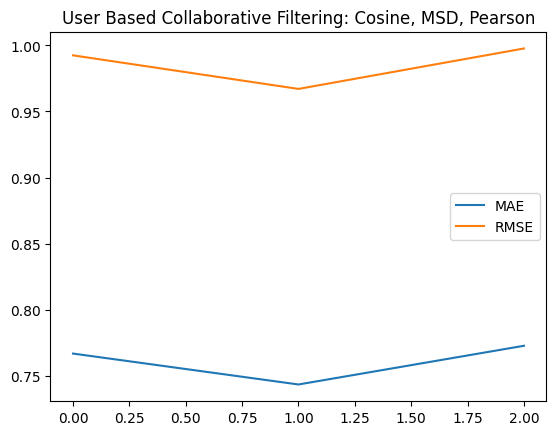

In [12]:
mae = [CV_UBCF_cosine["test_mae"].mean(), CV_UBCF_msd["test_mae"].mean(), CV_UBCF_pearson["test_mae"].mean()]
rmse = [CV_UBCF_cosine["test_rmse"].mean(), CV_UBCF_msd["test_rmse"].mean(), CV_UBCF_pearson["test_rmse"].mean()]

plt.title("User Based Collaborative Filtering: Cosine, MSD, Pearson")
plt.plot(mae, label = "MAE")
plt.plot(rmse, label = "RMSE")
plt.legend()
plt.show()

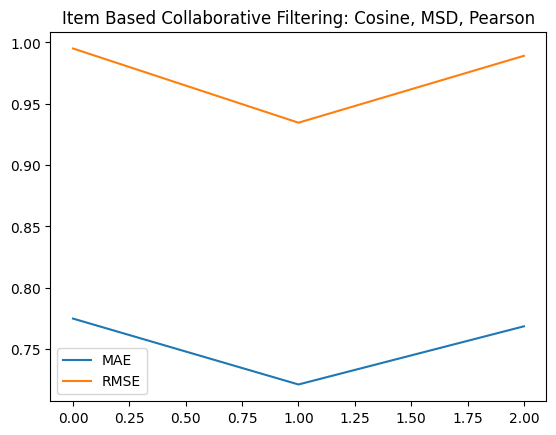

In [13]:
mae = [CV_IBCF_cosine["test_mae"].mean(), CV_IBCF_msd["test_mae"].mean(), CV_IBCF_pearson["test_mae"].mean()]
rmse = [CV_IBCF_cosine["test_rmse"].mean(), CV_IBCF_msd["test_rmse"].mean(), CV_IBCF_pearson["test_rmse"].mean()]

plt.title("Item Based Collaborative Filtering: Cosine, MSD, Pearson")
plt.plot(mae, label = "MAE")
plt.plot(rmse, label = "RMSE")
plt.legend()
plt.show()

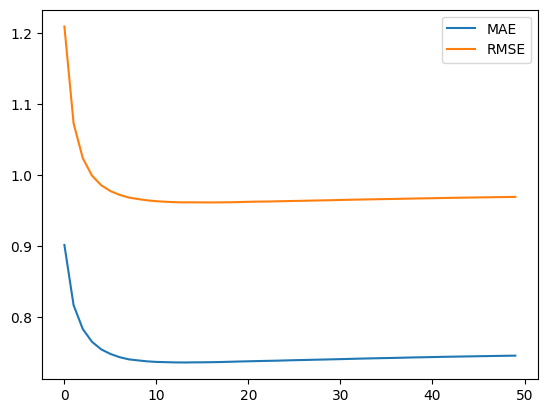

In [14]:
user_mae, user_rmse = [], []

for i in range(1, 51):
    algo = KNNBasic(k = i, sim_options = {"user_based": True}, verbose = False)
    CV_user = cross_validate(algo, data, measures = ["MAE", "RMSE"], cv = kf, verbose = False)
    user_rmse.append(CV_user["test_rmse"].mean())
    user_mae.append(CV_user["test_mae"].mean())

plt.plot(user_mae, label = "MAE")
plt.plot(user_rmse, label = "RMSE")
plt.legend()
plt.show()

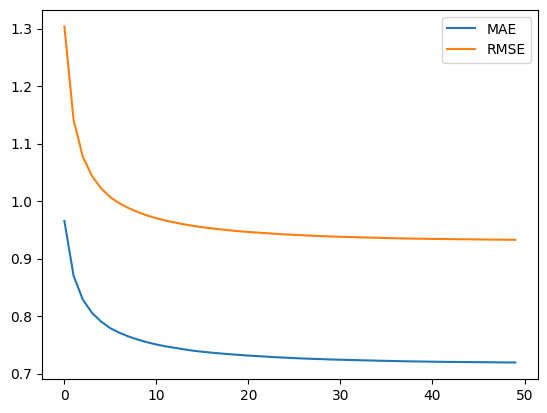

In [15]:
item_mae, item_rmse = [], []

for i in range(1, 51):
    algo = KNNBasic(k = i, sim_options = {"user_based": False}, verbose = False)
    CV_item = cross_validate(algo, data, measures = ["MAE", "RMSE"], cv = kf, verbose = False)
    item_rmse.append(CV_item["test_rmse"].mean())
    item_mae.append(CV_item["test_mae"].mean())

plt.plot(item_mae, label = "MAE")
plt.plot(item_rmse, label = "RMSE")
plt.legend()
plt.show()

In [16]:
print("Best k for User based Collaborative Filtering: ", user_rmse.index(min(user_rmse)) + 1)
print("Best k for Item based Collaborative Filtering: ", item_rmse.index(min(item_rmse)) + 1)

Best k for User based Collaborative Filtering:  17
Best k for Item based Collaborative Filtering:  50
